# Fred API 키 호출

In [ ]:
# ==========================================
# 🔑 FRED API 키 (입력 필수!)
# ==========================================
FRED_API_KEY = "9c3f2227440e6d8c815f7996a4d253b5"

# 데이터 가져오기

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("🚀 [Data Factory Final] 최종 확정된 8대 퀀트 센서 수집 및 엔지니어링 시작...")

# 1. 수집 기간 설정 (예열 기간 고려하여 2009년부터 수집)
download_start = '2009-01-01'
actual_start_date = '2010-01-01'
end_date = '2026-04-02'

# ==========================================
# 1. 자산 가격 및 시장 폭(Breadth) 데이터 수집 (Yahoo)
# ==========================================
assets = ['SPY', 'QQQ', 'EEM', 'TLT', 'IEF', 'LQD', 'SHV', 'GLD', 'DBC', 'VNQ', 'RSP']
df_raw = yf.download(assets, start=download_start, end=end_date)
df_assets = df_raw['Adj Close'] if 'Adj Close' in df_raw.columns else df_raw['Close']
df_assets.dropna(inplace=True)

# ==========================================
# 2. 거시 경제 및 원자재 수집 (Yahoo)
# ==========================================
macro_tickers = {
    '^VIX': 'VIX', 
    'DX-Y.NYB': 'DXY',  
    'KRW=X': 'USDKRW',
    'CL=F': 'WTI_Oil',
    'HG=F': 'Copper',
    'GC=F': 'Gold'
}
df_macro_yf_raw = yf.download(list(macro_tickers.keys()), start=download_start, end=end_date)
df_macro_yf = df_macro_yf_raw['Adj Close'] if 'Adj Close' in df_macro_yf_raw.columns else df_macro_yf_raw['Close']
df_macro_yf.rename(columns=macro_tickers, inplace=True)

# ==========================================
# 3. FRED API 데이터 수집 (금리, 스프레드, 유동성/고용)
# ==========================================
def get_fred_api_data(series_id, api_key):
    url = f"https://api.stlouisfed.org/fred/series/observations?series_id={series_id}&api_key={api_key}&file_type=json"
    response = requests.get(url)
    if response.status_code != 200: 
        print(f"⚠️ FRED API Error: {series_id}")
        return pd.Series()
    data = response.json()['observations']
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df.set_index('date', inplace=True)
    return df['value']

fred_series = {
    'DGS10': 'US10Y', 
    'DGS2': 'US2Y', 
    'DGS3MO': 'US3M', 
    'BAMLH0A0HYM2': 'HY_Spread',
    'WM2NS': 'M2_Supply',        
    'WALCL': 'Fed_Balance',      
    'ICSA': 'Jobless_Claims'     
}
fred_list = []
for series_id, col_name in fred_series.items():
    s = get_fred_api_data(series_id, FRED_API_KEY)
    s.name = col_name
    fred_list.append(s)

# 주간/월간 데이터이므로 빈 날짜가 많음 -> ffill()로 채워줌
df_macro_fred = pd.concat(fred_list, axis=1).loc[download_start:end_date].ffill()

# ==========================================
# 4. 병합 전 인덱스 타임존 정리 및 1차 병합
# ==========================================
df_assets.index = pd.to_datetime(df_assets.index).tz_localize(None).normalize()
df_macro_yf.index = pd.to_datetime(df_macro_yf.index).tz_localize(None).normalize()
df_macro_fred.index = pd.to_datetime(df_macro_fred.index).tz_localize(None).normalize()

df_raw_combined = pd.concat([df_assets, df_macro_yf, df_macro_fred], axis=1, join='inner').ffill()

# ==========================================
# 5. 모든 파생 지표 일괄 계산 (이전과 동일)
# ==========================================
df = df_raw_combined.copy()

df['VIX_ret'] = df['VIX'].pct_change()
df['VIX_MA5_Diff'] = df['VIX'] - df['VIX'].rolling(window=5).mean()
df['Volatility_20d'] = df['SPY'].pct_change().rolling(window=20).std() * np.sqrt(252)
df['Vol_Ratio'] = df['Volatility_20d'] / (df['SPY'].pct_change().rolling(window=60).std() * np.sqrt(252))
df['DXY_ret'] = df['DXY'].pct_change()
df['USDKRW_ret'] = df['USDKRW'].pct_change()
df['US10Y_diff'] = df['US10Y'].diff()
df['spread_10y2y'] = df['US10Y'] - df['US2Y']
df['spread_10y3m'] = df['US10Y'] - df['US3M']
df['HY_spread_ret'] = df['HY_Spread'].diff() 
df['GOLD_ret'] = df['Gold'].pct_change()
df['OIL_ret'] = df['WTI_Oil'].pct_change()
df['Copper_Gold_Ratio'] = df['Copper'] / df['Gold']
df['Market_Breadth'] = df['RSP'] / df['SPY']
df['Equity_vs_Bond'] = df['SPY'] / df['EEM']
df['SPY_ret'] = df['SPY'].pct_change()
df['SPY_Log_Ret'] = np.log(df['SPY'] / df['SPY'].shift(1))
df['SPY_MA20_Diff'] = (df['SPY'] / df['SPY'].rolling(window=20).mean()) - 1
df['MA200_Dist'] = df['SPY'] / df['SPY'].rolling(window=200).mean()

delta = df['SPY'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

exp1 = df['SPY'].ewm(span=12, adjust=False).mean()
exp2 = df['SPY'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Month'] = df.index.month

# 유동성 & 고용 지표 계산
df['M2_Growth'] = df['M2_Supply'].pct_change(60)
df['Fed_BS_Growth'] = df['Fed_Balance'].pct_change(60)
df['Jobless_Claims_MA'] = df['Jobless_Claims'].rolling(window=20).mean()

df.dropna(inplace=True)
df = df.loc[actual_start_date:]

🚀 [Data Factory Final] 최종 확정된 8대 퀀트 센서 수집 및 엔지니어링 시작...


[*********************100%***********************]  11 of 11 completed
[*********************100%***********************]  6 of 6 completed


In [ ]:
# ==========================================
# 6. 💡 [수정됨] 최종 확정된 8개 센서만 선택 & 스케일링
# ==========================================
final_8_features = [
    "Equity_vs_Bond", 
    "US10Y", 
    "Jobless_Claims_MA", 
    "VIX", 
    "Market_Breadth", 
    "spread_10y2y", 
    "DXY", 
    "Copper_Gold_Ratio"
]

scaler = StandardScaler()
# 전체 데이터프레임 복사
df_final_scaled = df.copy()
# 8개 피처만 스케일링
df_final_scaled[final_8_features] = scaler.fit_transform(df[final_8_features])

# 모델에 직접 투입할 수 있도록 8개 피처만 남긴 깔끔한 데이터프레임 생성 (선택 사항)
X_hmm = df_final_scaled[final_8_features]

print(f"\n✅ 8대 핵심 센서 추출 및 스케일링 완벽 종료!")
print(f"HMM 투입용 데이터(X_hmm) 형태: {X_hmm.shape}")
print(X_hmm.tail())


✅ 8대 핵심 센서 추출 및 스케일링 완벽 종료!
HMM 투입용 데이터(X_hmm) 형태: (4088, 8)
            Equity_vs_Bond     US10Y  Jobless_Claims_MA       VIX  \
2026-03-30        1.324388  1.691027          -0.377508  1.776366   
2026-03-31        1.296227  1.641716          -0.379001  0.993489   
2026-04-01        1.295478  1.671303          -0.380493  0.889787   
2026-04-02        1.338696  1.651578          -0.381985  0.791927   
2026-04-06        1.322868  1.691027          -0.383477  0.835745   

            Market_Breadth  spread_10y2y       DXY  Copper_Gold_Ratio  
2026-03-30       -2.031286     -0.477439  0.824840          -2.176782  
2026-03-31       -2.115903     -0.498633  0.765845          -2.195105  
2026-04-01       -2.158809     -0.488036  0.732594          -2.258337  
2026-04-02       -2.139263     -0.488036  0.773353          -2.210106  
2026-04-06       -2.143535     -0.498633  0.767991          -2.202836  


# HMM 모델링

🚀 [Final Model] 8개 핵심 센서 기반 HMM 6국면 모델링 가동 중...



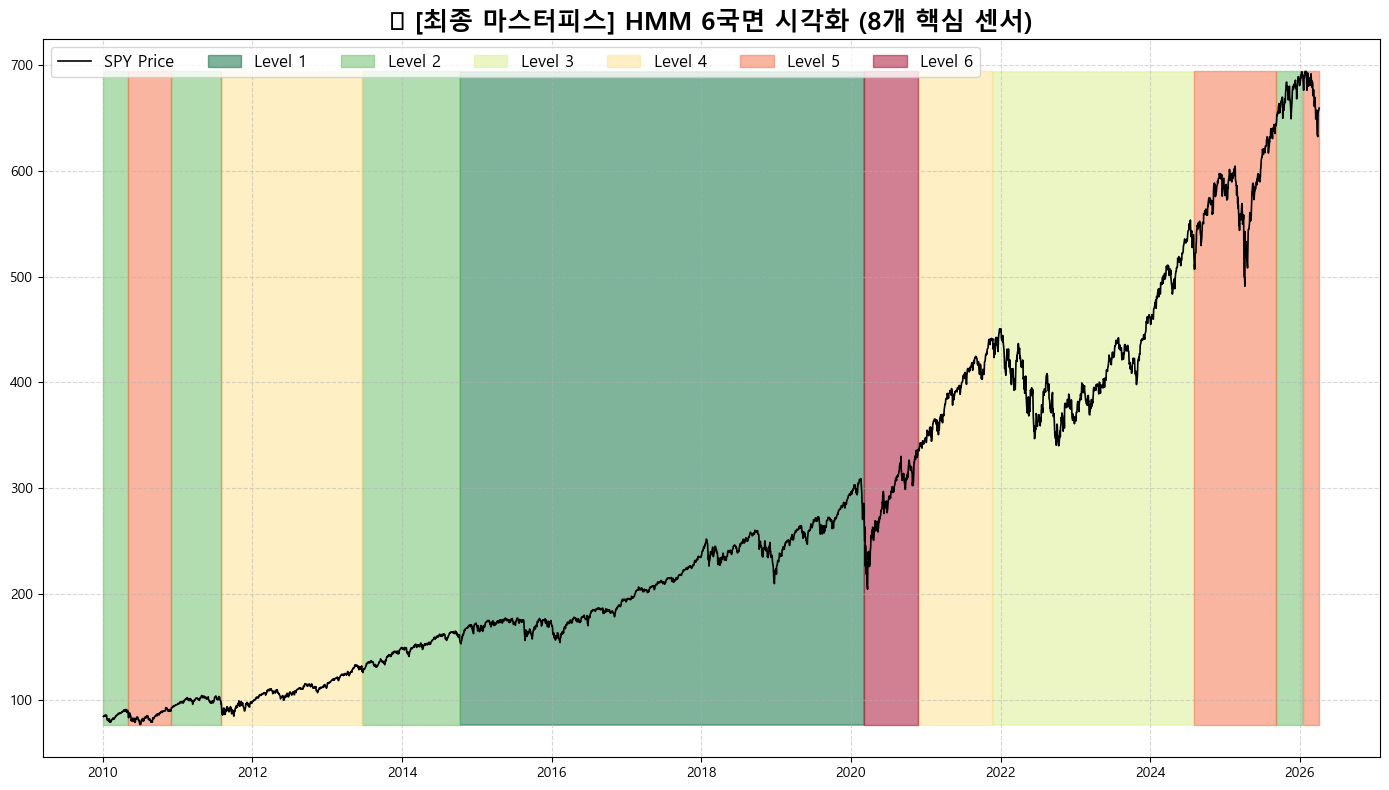


📊 [최종 마스터피스] 국면(Level 1~6)별 8대 핵심 센서 평균 수치 (스케일링 전 원본 데이터)
         Equity_vs_Bond  US10Y  Jobless_Claims_MA     VIX  Market_Breadth  spread_10y2y      DXY  Copper_Gold_Ratio
Level 1           6.460  2.250         245745.103  15.250           0.373         0.810   95.852              0.002
Level 2           5.083  3.145         354281.343  16.115           0.371         2.204   82.198              0.002
Level 3          11.198  3.559         218825.926  19.693           0.338        -0.284  103.581              0.002
Level 4           5.200  1.720         434595.914  19.964           0.364         1.474   84.207              0.002
Level 5           9.811  3.830         296916.388  21.180           0.324         0.964   95.677              0.002
Level 6           7.988  0.719        1656857.337  32.914           0.324         0.530   96.003              0.002



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

# 차트 세팅
plt.rcParams['figure.figsize'] = (14, 8) 
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🚀 [Final Model] 8개 핵심 센서 기반 HMM 6국면 모델링 가동 중...\n")

# HMM 학습용 데이터 (Data Factory V4에서 만든 X_hmm 사용)
X = X_hmm.values # 💡 hmmlearn 에러 방지를 위해 .values로 numpy 배열화
n = 6

# ==========================================
# 2. HMM 6국면 모델 훈련
# ==========================================
hmm = GaussianHMM(n_components=n, covariance_type="full", n_iter=1000, random_state=42)
hmm.fit(X)
states = hmm.predict(X)

# ==========================================
# 3. 시각화 및 통계용 데이터 준비 (💡 해석을 위해 원본 df 사용!)
# ==========================================
# X_hmm과 인덱스를 완벽하게 맞춘 원본 데이터 슬라이싱
df_plot = df.loc[X_hmm.index].copy() 
df_plot['Regime'] = states

# VIX 평균값 기준으로 국면 정렬 (안전 -> 위험)
regime_vix_mean = df_plot.groupby('Regime')['VIX'].mean()
sorted_regimes = regime_vix_mean.sort_values().index.tolist()
rank_map = {regime: rank for rank, regime in enumerate(sorted_regimes)}
df_plot['Level_Rank'] = df_plot['Regime'].map(rank_map)

# ==========================================
# 4. 그래프 그리기
# ==========================================
plt.plot(df_plot.index, df_plot['SPY'], color='black', linewidth=1.2, label='SPY Price')

# 초록(안전) -> 빨강(위험) 컬러맵
colors = [plt.cm.RdYlGn_r(i / (n - 1)) for i in range(n)]

for rank in range(n):
    condition = (df_plot['Level_Rank'] == rank)
    plt.fill_between(df_plot.index, df_plot['SPY'].min(), df_plot['SPY'].max(), 
                     where=condition, color=colors[rank], alpha=0.5, label=f'Level {rank+1}')

plt.title("👑 [최종 마스터피스] HMM 6국면 시각화 (8개 핵심 센서)", fontsize=18, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', ncol=7, fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 💡 국면(Level)별 핵심 센서 특성 파악용 통계표 출력
# ==========================================
print("\n" + "="*110)
print("📊 [최종 마스터피스] 국면(Level 1~6)별 8대 핵심 센서 평균 수치 (스케일링 전 원본 데이터)")
print("="*110)

# 💡 에러 수정 완료: final_features -> final_8_features 로 변경!
regime_stats = df_plot.groupby('Level_Rank')[final_8_features].mean()
regime_stats.index = [f"Level {i+1}" for i in range(n)]

# 콘솔 창에서 잘림 없이 한눈에 보기 위한 Pandas 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 소수점 3자리까지 깔끔하게 출력
print(regime_stats.round(3))
print("="*110 + "\n")